# Train XGBoost model (t+1 target)
Train an XGBoost classifier on `data/processed/xgboost_t1`, using `target_t+1` as the label and all columns except `target_t+1`, `client_nr`, and `yearmonth` as features.

Hyperparameters are tuned with **Optuna**, maximizing PR-AUC on the validation split. The classification threshold is **not** tuned automatically: it is chosen manually below by inspecting the validation precision-recall curve against the business objective.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# make the models/ package importable from this notebook
sys.path.append(str(Path("models").resolve()))

from train_xgboost import (
    evaluate_all_splits,
    get_feature_columns,
    load_split,
    plot_precision_recall_curve,
    save_model,
    train_model,
)

c:\Users\SVisbee\Repos\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Tune hyperparameters and train

In [2]:
model, feature_columns, trials_df = train_model(n_trials=50)

Train observations: 18,835
Validation observations: 3,790
Number of features: 27

Class distribution in training data:
  Negative: 17,507
  Positive: 1,328
  scale_pos_weight: 13.18


Best trial: 18. Best value: 0.170354: 100%|██████████| 50/50 [00:09<00:00,  5.28it/s]


Best validation PR-AUC: 0.1704
Best hyperparameters:
  learning_rate: 0.1
  max_depth: 4
  min_child_weight: 50
  subsample: 1.0
  colsample_bytree: 0.7
  gamma: 0.5
  reg_alpha: 0.1
  reg_lambda: 5
  scale_pos_weight: 13.182981927710843


In [3]:
trials_df.sort_values("value", ascending=False).head(10)

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,state
42,42,0.170354,2026-08-30 22:24:34.205714,2026-08-30 22:24:34.363102,0 days 00:00:00.157388,0.7,0.5,0.1,4,50,0.1,5,1.0,COMPLETE
21,21,0.170354,2026-08-30 22:24:30.023626,2026-08-30 22:24:30.183626,0 days 00:00:00.160000,0.7,0.5,0.1,4,50,0.1,5,1.0,COMPLETE
18,18,0.170354,2026-08-30 22:24:29.553395,2026-08-30 22:24:29.715106,0 days 00:00:00.161711,0.7,0.5,0.1,4,50,0.1,5,1.0,COMPLETE
41,41,0.170354,2026-08-30 22:24:34.045441,2026-08-30 22:24:34.203176,0 days 00:00:00.157735,0.7,0.5,0.1,4,50,0.1,5,1.0,COMPLETE
23,23,0.170354,2026-08-30 22:24:30.364939,2026-08-30 22:24:30.535428,0 days 00:00:00.170489,0.7,0.5,0.1,4,50,0.1,5,1.0,COMPLETE
31,31,0.170354,2026-08-30 22:24:32.214961,2026-08-30 22:24:32.377760,0 days 00:00:00.162799,0.7,0.5,0.1,4,50,0.1,5,1.0,COMPLETE
43,43,0.170354,2026-08-30 22:24:34.365155,2026-08-30 22:24:34.529963,0 days 00:00:00.164808,0.7,0.5,0.1,4,50,0.1,5,1.0,COMPLETE
22,22,0.170354,2026-08-30 22:24:30.185637,2026-08-30 22:24:30.363933,0 days 00:00:00.178296,0.7,0.5,0.1,4,50,0.1,5,1.0,COMPLETE
34,34,0.170354,2026-08-30 22:24:32.669414,2026-08-30 22:24:32.826305,0 days 00:00:00.156891,0.7,1.0,0.1,4,50,0.1,5,1.0,COMPLETE
32,32,0.170354,2026-08-30 22:24:32.379765,2026-08-30 22:24:32.540196,0 days 00:00:00.160431,0.7,0.5,0.1,4,50,0.1,5,1.0,COMPLETE


## Select the classification threshold
Inspect the precision-recall curve on the **validation** split (train would be optimistic, test must stay untouched) and pick the threshold matching the business objective.

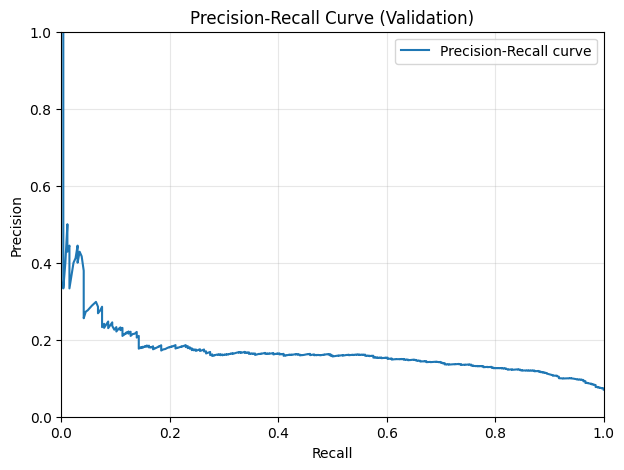

In [4]:
val_df = load_split("val")

threshold_table = plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    title="Precision-Recall Curve (Validation)",
)

In [10]:
# inspect candidate operating points to pick a threshold
threshold_table = threshold_table.sort_values(by="recall", ascending=False)
threshold_table[threshold_table["precision"] >= 0.5].head(20)

,threshold,precision,recall
1954,0.731572,0.5,0.011278
1957,0.742849,0.5,0.003759
1958,0.743100,1.0,0.003759


### Chosen threshold
Set `SELECTED_THRESHOLD` below based on the curve and table above.

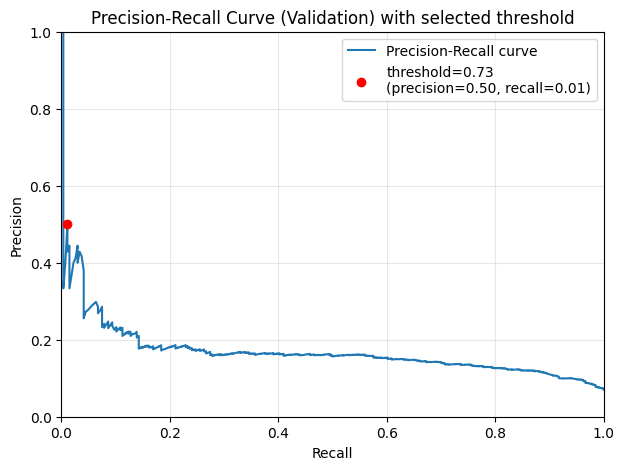

In [11]:
SELECTED_THRESHOLD = 0.731572

plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    threshold=SELECTED_THRESHOLD,
    title="Precision-Recall Curve (Validation) with selected threshold",
);

## Final evaluation

In [12]:
evaluate_all_splits(model, feature_columns, threshold=SELECTED_THRESHOLD)

,pr_auc,precision,recall,f1,precision_at_k (k=90),recall_at_k (k=90)
train,0.185603,0.454545,0.003765,0.007468,0.355556,0.024096
val,0.170354,0.400000,0.007519,0.014760,0.233333,0.078947
test,0.131786,0.250000,0.008065,0.015625,0.155556,0.037634


In [13]:
threshold_table

,threshold,precision,recall
0,0.124890,0.070185,1.000000
17,0.138441,0.071333,1.000000
2,0.126947,0.070315,1.000000
3,0.128158,0.070333,1.000000
4,0.130085,0.070352,1.000000
...,...,...,...
1954,0.731572,0.500000,0.011278
1955,0.738109,0.400000,0.007519
1956,0.740257,0.333333,0.003759
1957,0.742849,0.500000,0.003759


## Save the model
Persist the fitted model together with its feature list and chosen threshold, so it can be reloaded for comparison and inference.

In [14]:
save_model(model, feature_columns, threshold=SELECTED_THRESHOLD)

Saved model to C:\Users\SVisbee\Repos\Credit_prediction_case\models\artifacts\xgboost_t1.joblib


WindowsPath('models/artifacts/xgboost_t1.joblib')